In [1]:
import xarray as xr
import numpy as np
import rioxarray 
import rasterio as rio
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import xdem

In [2]:
# function to rewrite coordinates from metadata
def coord_range(ds):
    latrange = np.linspace(float(ds.attrs['Y_FIRST']),
                           ((float(ds.attrs['Y_STEP'])*float(ds.attrs['LENGTH']))+float(ds.attrs['Y_FIRST'])),
                           int(ds.attrs['LENGTH']))
    lonrange = np.linspace(float(ds.attrs['X_FIRST']),
                           ((float(ds.attrs['X_STEP'])*float(ds.attrs['WIDTH']))+float(ds.attrs['X_FIRST'])),
                           int(ds.attrs['WIDTH']))
    return latrange, lonrange

def mintpy2d_to_xarray(fn, crs):
    ds = xr.open_dataset(fn, engine='h5netcdf', phony_dims='sort')
    ds = ds.rename_dims({'phony_dim_0':'y',
                         'phony_dim_1':'x'
                        })
    latrange, lonrange = coord_range(ds)
    ds = ds.assign_coords({'y': ('y', latrange),
                          'x': ('x', lonrange)})
    ds = ds.rio.write_crs(crs)
    
    return ds

In [3]:
# function to read time series into xarray
def mintpyTS_to_xarray(fn, crs):
    ds = xr.open_dataset(fn, cache=False)
    ds = ds.rename_dims({'phony_dim_1':'time',
                         'phony_dim_2':'y',
                         'phony_dim_3':'x'})
    ds = ds.rename({'timeseries': 'displacement'})
    latrange, lonrange = coord_range(ds)
    ds = ds.assign_coords({'time': ('time', pd.to_datetime(ds.date)),
                           'y': ('y', latrange),
                           'x': ('x', lonrange)})
    ds = ds.drop(['bperp', 'date'])
    ds = ds.rio.write_crs(crs)
    ds['displacement'] = ds['displacement'] * -1
    
    return ds

In [4]:
asc_mintpy_path = '../asc_mintpy_insaronly'
des_mintpy_path = '../des_mintpy_insaronly'

# define crs 
crs = 32645

In [83]:
# read geometry files into xarray ds
asc_geom_fn = f'{asc_mintpy_path}/inputs/geometryGeo.h5'
des_geom_fn = f'{des_mintpy_path}/inputs/geometryGeo.h5'
asc_geom_ds = mintpy2d_to_xarray(asc_geom_fn, crs)
des_geom_ds = mintpy2d_to_xarray(des_geom_fn, crs)

In [91]:
# define azimuth angle from sensor to target relative to north
asc_geom_ds['azimuthAngle'] =  -(asc_geom_ds['azimuthAngle']-90)
des_geom_ds['azimuthAngle'] = np.abs(des_geom_ds['azimuthAngle']+90)

In [33]:
# calculate terrain characteristics at appropriate length scale
# define general geom ds
geom_ds = asc_geom_ds.drop_vars(['azimuthAngle', 'incidenceAngle', 'slantRangeDistance'])

# define transform
geom_transform = (20, 0.0, geom_ds.isel(x=0, y=0).x.item(), 0.0, 20, geom_ds.isel(x=0, y=0).y.item())

# load to xdem
dem = xdem.DEM.from_array(geom_ds.height.values, geom_transform, crs=geom_ds.rio.crs)
# calculate slope and aspect
geom_ds['aspect'] = (('y', 'x'), xdem.terrain.aspect(dem).data.data)
geom_ds['slope'] = (('y', 'x'), xdem.terrain.slope(dem).data.data)

In [96]:
def R_index(ds, direction):
    # Convert degrees to radians
    deg_to_rad = np.pi / 180
    incidence_angle = ds.incidenceAngle * deg_to_rad
    azimuth_direction = ds.azimuthAngle * deg_to_rad
    slope = geom_ds['slope']*deg_to_rad
    aspect = geom_ds['aspect']*deg_to_rad
    if direction == 'asc':
        A_a = aspect + azimuth_direction + np.pi
    else:
        A_a = aspect - azimuth_direction
    R_index = -np.sin((slope*np.sin(A_a)) - np.sin(incidence_angle))
    ds['R_index'] = R_index + (ds.height*0)
    ds['R_index'] = ds['R_index'].where(ds['R_index'] > 0)
    return ds

In [97]:
asc_geom_ds = R_index(asc_geom_ds, 'asc')
des_geom_ds = R_index(des_geom_ds, 'des')

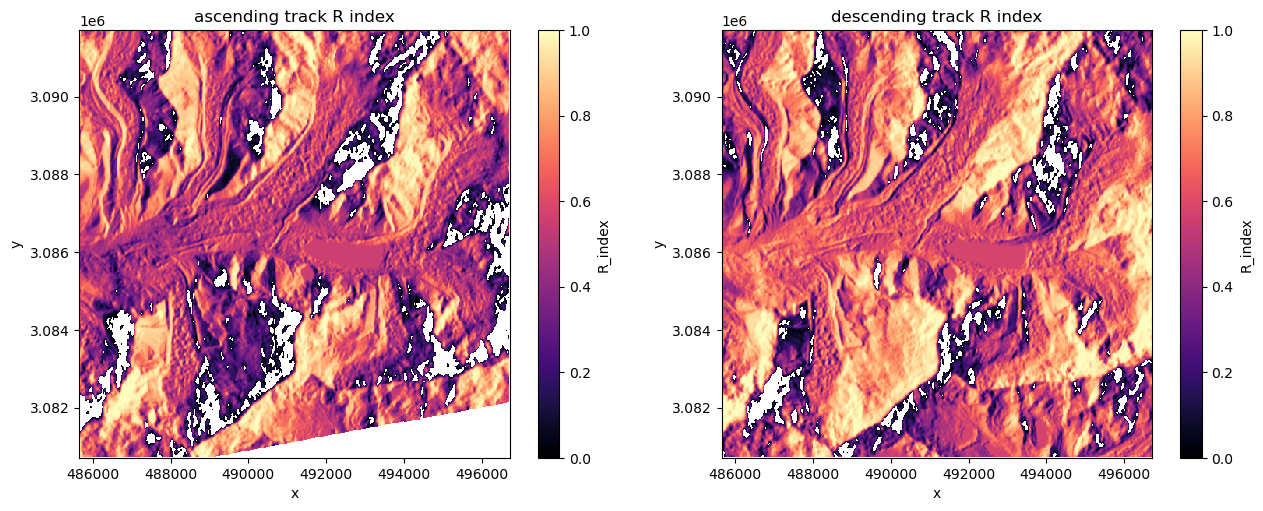

In [99]:
f, ax = plt.subplots(1, 2, figsize=(13, 5))
asc_geom_ds['R_index'].plot(ax=ax[0], vmin=0, vmax=1, cmap='magma')
ax[0].set_aspect('equal')
ax[0].set_title('ascending track R index')
des_geom_ds['R_index'].plot(ax=ax[1], vmin=0, vmax=1, cmap='magma')
ax[1].set_aspect('equal')
ax[1].set_title('descending track R index')
plt.tight_layout()
f.savefig('../figs/R_index.png', dpi=300)

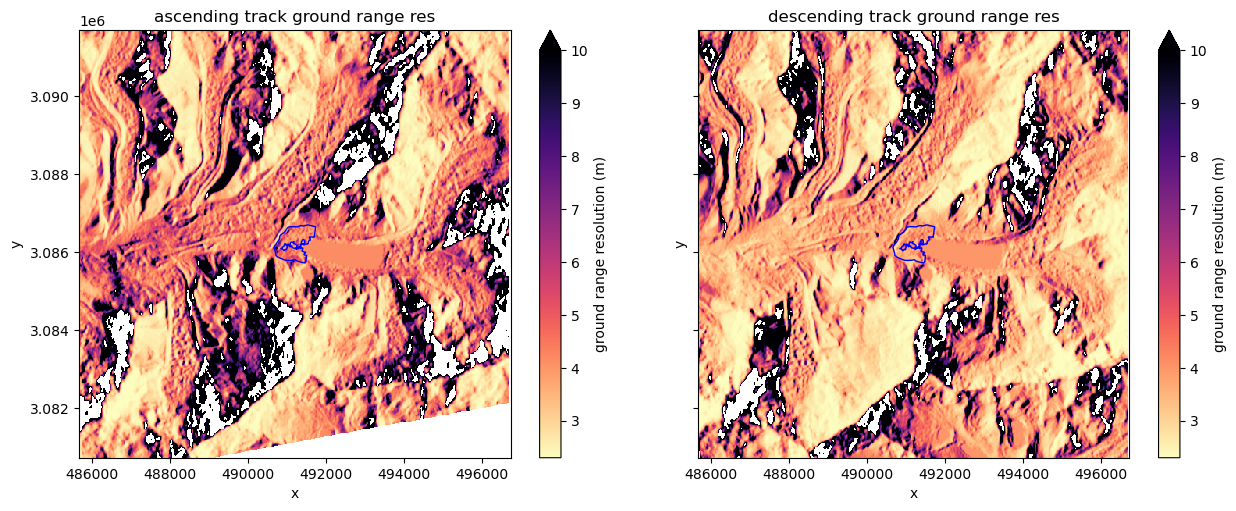

In [128]:
padding=0

f, ax = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
(2.3/asc_geom_ds['R_index']).plot(ax=ax[0], vmin=2.3, vmax=10, cmap='magma_r', cbar_kwargs={'label':'ground range resolution (m)'})
ax[0].set_aspect('equal')
ax[0].set_title('ascending track ground range res')
dam_gdf.plot(ax=ax[0], edgecolor='blue', facecolor='none')
(2.3/des_geom_ds['R_index']).plot(ax=ax[1], vmin=2.3, vmax=10, cmap='magma_r', cbar_kwargs={'label':'ground range resolution (m)'})
ax[1].set_aspect('equal')
ax[1].set_title('descending track ground range res')
plt.tight_layout()
dam_gdf.plot(ax=ax[1], edgecolor='blue', facecolor='none')

ax[0].set_xlim(aoi_extent[0]+padding, aoi_extent[2]-padding)
ax[0].set_ylim(aoi_extent[3]+padding, aoi_extent[1]-padding)
f.savefig('../figs/ground_range_res.png', dpi=300)

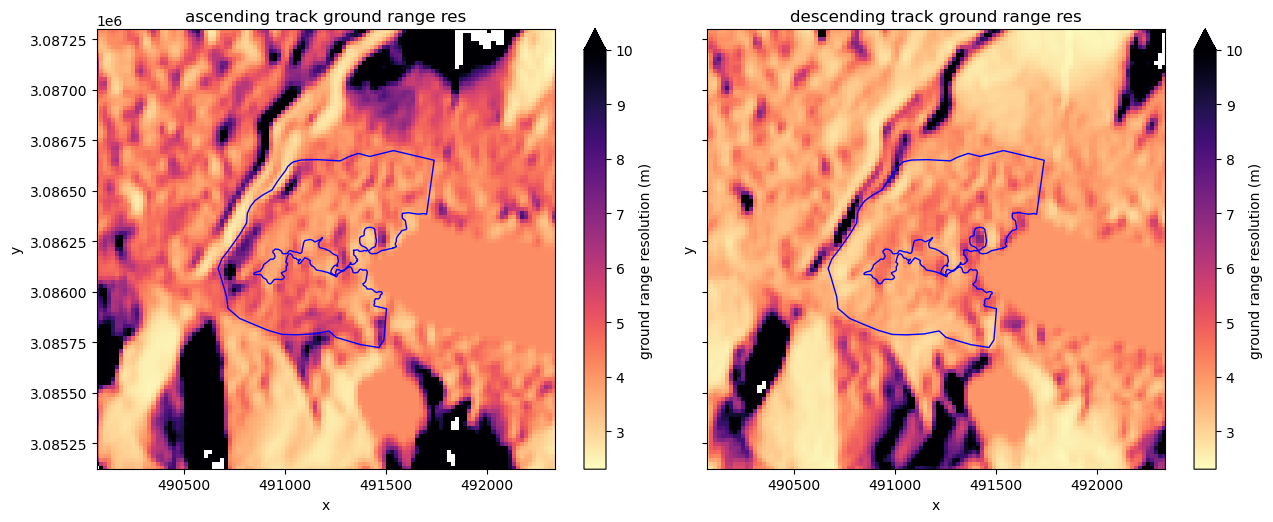

In [157]:
padding=4400

f, ax = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
(2.3/asc_geom_ds['R_index']).plot(ax=ax[0], vmin=2.3, vmax=10, cmap='magma_r', cbar_kwargs={'label':'ground range resolution (m)'})
ax[0].set_aspect('equal')
ax[0].set_title('ascending track ground range res')
dam_gdf.plot(ax=ax[0], edgecolor='blue', facecolor='none')
(2.3/des_geom_ds['R_index']).plot(ax=ax[1], vmin=2.3, vmax=10, cmap='magma_r', cbar_kwargs={'label':'ground range resolution (m)'})
ax[1].set_aspect('equal')
ax[1].set_title('descending track ground range res')
dam_gdf.plot(ax=ax[1], edgecolor='blue', facecolor='none')

ax[0].set_xlim(aoi_extent[0]+padding, aoi_extent[2]-padding)
ax[0].set_ylim(aoi_extent[3]+padding, aoi_extent[1]-padding)
f.savefig('../figs/imja_ground_range_res.png', dpi=300)
plt.tight_layout()

In [171]:
asc_geom_ds['R_index'].rio.to_raster('asc_R_index.tif')
des_geom_ds['R_index'].rio.to_raster('des_R_index.tif')
(2.3/asc_geom_ds['R_index']).rio.to_raster('asc_gr_res.tif')
(2.3/des_geom_ds['R_index']).rio.to_raster('des_gr_res.tif')

In [112]:
# set up paths, directories, and variables for this specific dam
dam_name = 'imja'
proc_path = f'/home/jovyan/repos/fufiters_imja_analysis/analysis'

# define crs 
crs = 32645

In [125]:
# read in dam polygon
dam_fn = f'../../mapping/polygons/{dam_name}_md.shp'
dam_gdf = gpd.read_file(dam_fn)
dam_gdf = dam_gdf.to_crs(crs) # reproject in case of mistake

# load in moving area polygon
moving_fn = f'../../mapping/polygons/{dam_name}_moving.shp'
moving_gdf = gpd.read_file(moving_fn)

# load in moving area polygon
reference_fn = f'../../mapping/polygons/{dam_name}_reference.shp'
reference_gdf = gpd.read_file(reference_fn)

# load in stable area polygon
stable_fn = f'../../mapping/polygons/{dam_name}_stable.shp'
stable_gdf = gpd.read_file(stable_fn).to_crs(crs)

# load in water mask
water_fn = f'../../mapping/polygons/water_mask.shp'
water_gdf = gpd.read_file(water_fn).to_crs(crs)

# pad dam bounds by 5 km 
padding = 5000
aoi_extent = [dam_gdf.bounds.minx.item()-padding,
               dam_gdf.bounds.maxy.item()+padding,
               dam_gdf.bounds.maxx.item()+padding,
               dam_gdf.bounds.miny.item()-padding]

In [164]:
asc_res_clip = (2.3/asc_geom_ds['R_index']).rio.clip(dam_gdf.geometry, crs=dam_gdf.crs, drop=True)
des_res_clip = (2.3/des_geom_ds['R_index']).rio.clip(dam_gdf.geometry, crs=dam_gdf.crs, drop=True)

In [156]:
des_res_clip.median()*0.2

<xarray.DataArray 'R_index' ()> Size: 8B
array(0.76448474)
Coordinates:
    spatial_ref  int64 8B 0

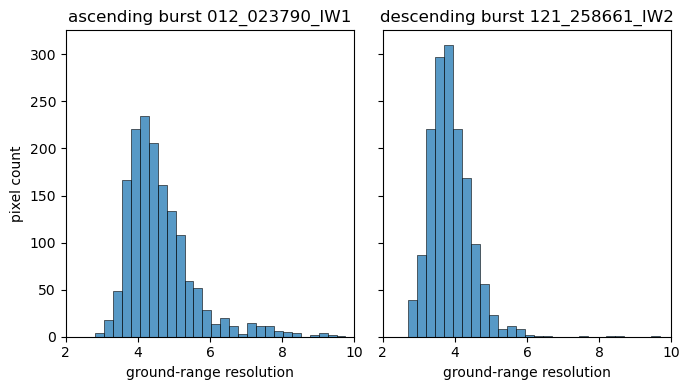

In [170]:
asc_burst = '012_023790_IW1'
des_burst = '121_258661_IW2'

f, ax = plt.subplots(1, 2, figsize=(7, 4), sharex=True, sharey=True)
sns.histplot(asc_res_clip.values.ravel(), ax=ax[0], binwidth=0.25)
sns.histplot(des_res_clip.values.ravel(), ax=ax[1], binwidth=0.25)
ax[0].set_xlim(2, 10)
ax[0].set_title(f'ascending burst {asc_burst}')
ax[1].set_title(f'descending burst {des_burst}')
ax[0].set_xlabel('ground-range resolution')
ax[1].set_xlabel('ground-range resolution')
ax[0].set_ylabel('pixel count')
f.tight_layout()
f.savefig('../figs/resolution_hist.png')